**Example A**
* We are going to use 2 layers.
* Optimizer use SGD.
* Use without normalization.

**Example B**
* We are going to use 3 layers.
* Optimizer use Adam.
* Use without normalization.

**Example C**
* We are going to use 2 layers.
* Optimizer use SGD.
* Use Normalization and Standardization.


In [46]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [28]:
insurance_data=pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [29]:
insurance_data_one_hot=pd.get_dummies(insurance_data)
insurance_data_one_hot.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [30]:
X=insurance_data_one_hot.drop('charges',axis=1)
y=insurance_data_one_hot['charges']

In [31]:
print('Features are:')
X.head()

Features are:


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

In [34]:
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

In [35]:
insurance_model.fit(X_train,y_train,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - loss: 8515.2666 - mae: 8515.2666
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 8510.7207 - mae: 8510.7207
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 8505.2129 - mae: 8505.2129
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 8495.4170 - mae: 8495.4170
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 8476.2207 - mae: 8476.2207
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 8437.9199 - mae: 8437.9199
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 8361.2500 - mae: 8361.2500
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 8207.6826 - mae: 8207.6826
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 7900.0571 - mae: 7900.0571
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 7283.8037 - mae: 7283.8037
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 6049.2686 - mae: 6049.2686
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - los

In [36]:
insurance_model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 7745.9160 - mae: 7745.9160


[7745.916015625, 7745.916015625]

**Example B**

In [40]:
tf.random.set_seed(42)
insurance_model_2=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

history_model_2=insurance_model_2.fit(X_train,y_train,epochs=150,verbose=0)

In [41]:
insurance_model_2.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 7846.0684 - mae: 7846.0684


[7846.068359375, 7846.068359375]

In [42]:
insurance_model_2_loss,insurance_model_2_mae=insurance_model.evaluate(X_test,y_test)
print('Loss:',insurance_model_2_loss)
print('MAE:',insurance_model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 7745.9160 - mae: 7745.9160
Loss: 7745.916015625
MAE: 7745.916015625


Text(0.5, 1.0, 'Loss Curve')

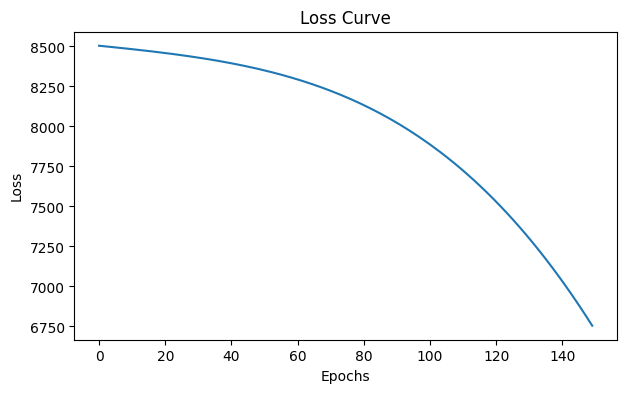

In [44]:
plt.figure(figsize=(7,4))
plt.plot(history_model_2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')


**Example C**

In [ ]:
insurance_data=pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(10)

In [45]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [47]:
ct=make_column_transformer(
    (MinMaxScaler(),['age','bmi','children']),
    (OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region'])
)

In [48]:
X=insurance_data.drop('charges',axis=1)
y=insurance_data['charges']

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [51]:
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

In [53]:
#Original data
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [54]:
#Normalized data
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [55]:
print('X-Train Shape',X_train.shape)
print('X-Train Normal Shape',X_train_normal.shape)

X-Train Shape (4, 6)
X-Train Normal Shape (4, 8)


In [58]:
tf.random.set_seed(42)
insurance_model_C=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_C.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

insurance_model_C_history=insurance_model_C.fit(X_train_normal,y_train,epochs=200,verbose=0)

In [60]:
insurance_model_C.evaluate(X_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - loss: 9157.4785 - mae: 9157.4785


[9157.478515625, 9157.478515625]